# HMM Price And Microstructure Results Analysis

Notebook downloads artifacts produced by `hmm_price_microstructure_factor_models.ipynb` and compares the price-factor and microstructure-factor HMM grids.

In [1]:
from __future__ import annotations

import json
import os
import tempfile
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv(Path.cwd() / '.env')

BUCKET = os.getenv('YC_BUCKET', 'binance-data-downloader')
MODEL_RESULT_SPECS = {
    'price': {
        'description': 'Price factor HMM',
        'result_prefix': 'analysis/hmm_price_factor_models_v1',
    },
    'microstructure': {
        'description': 'Microstructure factor HMM',
        'result_prefix': 'analysis/hmm_microstructure_factor_models_v1',
    },
}

required_env = ['YC_ENDPOINT', 'YC_REGION', 'YC_ACCESS_KEY_ID', 'YC_SECRET_ACCESS_KEY']
missing = [name for name in required_env if not os.getenv(name)]
if missing:
    raise RuntimeError(f'Missing S3 environment variables: {missing}')

s3 = boto3.client(
    's3',
    endpoint_url=os.getenv('YC_ENDPOINT'),
    region_name=os.getenv('YC_REGION'),
    aws_access_key_id=os.getenv('YC_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('YC_SECRET_ACCESS_KEY'),
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

workdir = Path(tempfile.mkdtemp(prefix='hmm_factor_results_'))
print(f'Local artifact cache: {workdir}')


Local artifact cache: C:\Users\73B5~1\AppData\Local\Temp\hmm_factor_results_nxgef9d0


In [2]:
def download_artifact(prefix: str, artifact_name: str, local_dir: Path) -> Path:
    local_path = local_dir / artifact_name
    local_path.parent.mkdir(parents=True, exist_ok=True)
    key = f'{prefix.strip("/")}/{artifact_name}'
    s3.download_file(BUCKET, key, str(local_path))
    return local_path


def load_result_bundle(spec_name: str, spec: dict) -> dict:
    prefix = spec['result_prefix']
    local_dir = workdir / spec_name
    print(f'Downloading {spec_name}: s3://{BUCKET}/{prefix}/')

    summary_path = download_artifact(prefix, 'summary.json', local_dir)
    metrics_path = download_artifact(prefix, 'grid_search_metrics.parquet', local_dir)
    profiles_path = download_artifact(prefix, 'best_model_state_profiles.parquet', local_dir)
    states_path = download_artifact(prefix, 'best_model_train_states.parquet', local_dir)

    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    metrics = pd.read_parquet(metrics_path)
    profiles = pd.read_parquet(profiles_path)
    states = pd.read_parquet(states_path)
    states['timestamp'] = pd.to_datetime(states['timestamp'], utc=True)

    metrics.insert(0, 'model_family', spec_name)
    profiles.insert(0, 'model_family', spec_name)
    states.insert(0, 'model_family', spec_name)

    return {
        'summary': summary,
        'metrics': metrics,
        'profiles': profiles,
        'states': states,
        'local_dir': local_dir,
    }


def best_rows(metrics: pd.DataFrame) -> pd.DataFrame:
    columns = [
        'model_family',
        'n_components',
        'bic',
        'aic',
        'log_likelihood',
        'converged',
        'em_iterations',
        'average_sequence_duration',
        'average_theoretical_duration',
        'min_state_share',
        'has_degenerate_state',
    ]
    return (
        metrics.loc[metrics['status'].eq('ok')]
        .sort_values(['model_family', 'bic'])
        .groupby('model_family', as_index=False)
        .head(1)
        .loc[:, columns]
        .reset_index(drop=True)
    )


In [3]:
results = {name: load_result_bundle(name, spec) for name, spec in MODEL_RESULT_SPECS.items()}

metrics = pd.concat([bundle['metrics'] for bundle in results.values()], ignore_index=True)
profiles = pd.concat([bundle['profiles'] for bundle in results.values()], ignore_index=True)
states = pd.concat([bundle['states'] for bundle in results.values()], ignore_index=True)
summaries = {name: bundle['summary'] for name, bundle in results.items()}

print(f'Metrics rows: {len(metrics):,}')
print(f'State rows: {len(states):,}')
best_rows(metrics)


Metrics rows: 10
State rows: 1,054,080


,model_family,n_components,bic,aic,log_likelihood,converged,em_iterations,average_sequence_duration,average_theoretical_duration,min_state_share,has_degenerate_state
0,microstructure,6,1.552845e+05,1.543569e+05,-7.709547e+04,True,135,9.162726,12.293100,0.003597,True
1,price,6,3.399340e+06,3.398412e+06,-1.699123e+06,True,500,4.239144,23.732661,0.102755,False


## Grid comparison

In [4]:
grid_view_columns = [
    'model_family',
    'n_components',
    'status',
    'bic',
    'aic',
    'log_likelihood',
    'converged',
    'em_iterations',
    'average_sequence_duration',
    'average_theoretical_duration',
    'min_state_share',
    'has_degenerate_state',
]

metrics.loc[:, grid_view_columns].sort_values(['model_family', 'bic'], na_position='last')


,model_family,n_components,status,bic,aic,log_likelihood,converged,em_iterations,average_sequence_duration,average_theoretical_duration,min_state_share,has_degenerate_state
5,microstructure,6,ok,1.552845e+05,1.543569e+05,-7.709547e+04,True,135,9.162726,12.293100,0.003597,True
6,microstructure,5,ok,2.963688e+05,2.956536e+05,-1.477628e+05,True,123,6.684762,13.225120,0.004992,True
7,microstructure,4,ok,3.432359e+05,3.427107e+05,-1.713084e+05,True,39,11.658114,16.581944,0.005686,True
8,microstructure,3,ok,8.842041e+05,8.838465e+05,-4.418912e+05,True,46,11.750123,16.244390,0.006474,True
9,microstructure,2,ok,1.259479e+06,1.259267e+06,-6.296145e+05,True,28,15.089759,25.983096,0.067259,False
0,price,6,ok,3.399340e+06,3.398412e+06,-1.699123e+06,True,500,4.239144,23.732661,0.102755,False
1,price,4,ok,3.634453e+06,3.633928e+06,-1.816917e+06,True,59,30.508828,30.132056,0.153594,False
2,price,5,ok,3.703407e+06,3.702692e+06,-1.851282e+06,True,500,2.846096,20.816558,0.161788,False
3,price,3,ok,4.473772e+06,4.473415e+06,-2.236675e+06,True,500,1.501598,17.523743,0.326677,False
4,price,2,ok,4.473940e+06,4.473727e+06,-2.236845e+06,True,26,83.379212,82.831708,0.331777,False


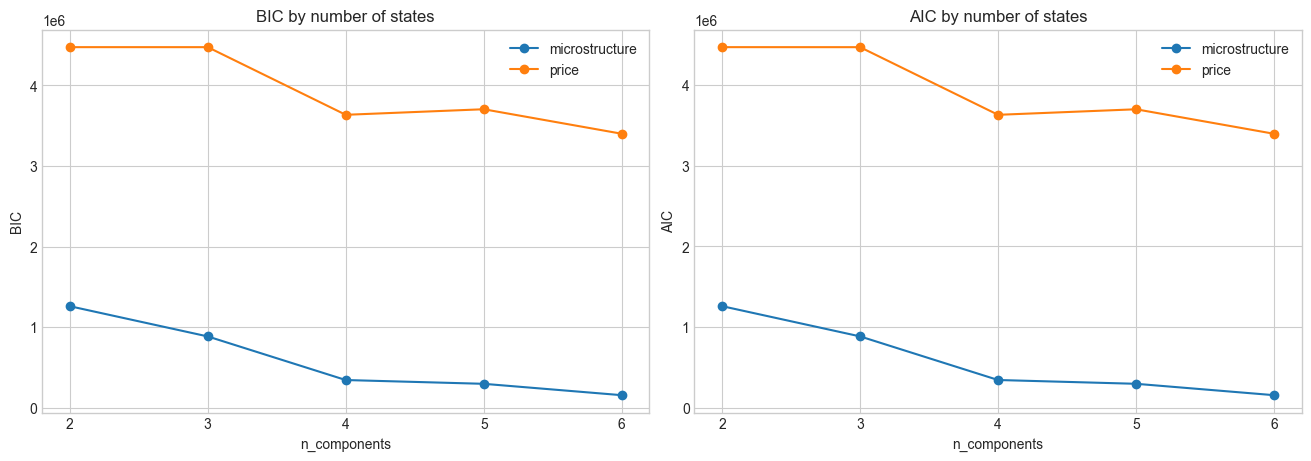

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for model_family, group in metrics.loc[metrics['status'].eq('ok')].groupby('model_family'):
    ordered = group.sort_values('n_components')
    axes[0].plot(ordered['n_components'], ordered['bic'], marker='o', label=model_family)
    axes[1].plot(ordered['n_components'], ordered['aic'], marker='o', label=model_family)

axes[0].set_title('BIC by number of states')
axes[0].set_xlabel('n_components')
axes[0].set_ylabel('BIC')
axes[1].set_title('AIC by number of states')
axes[1].set_xlabel('n_components')
axes[1].set_ylabel('AIC')
for ax in axes:
    ax.legend()
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.show()


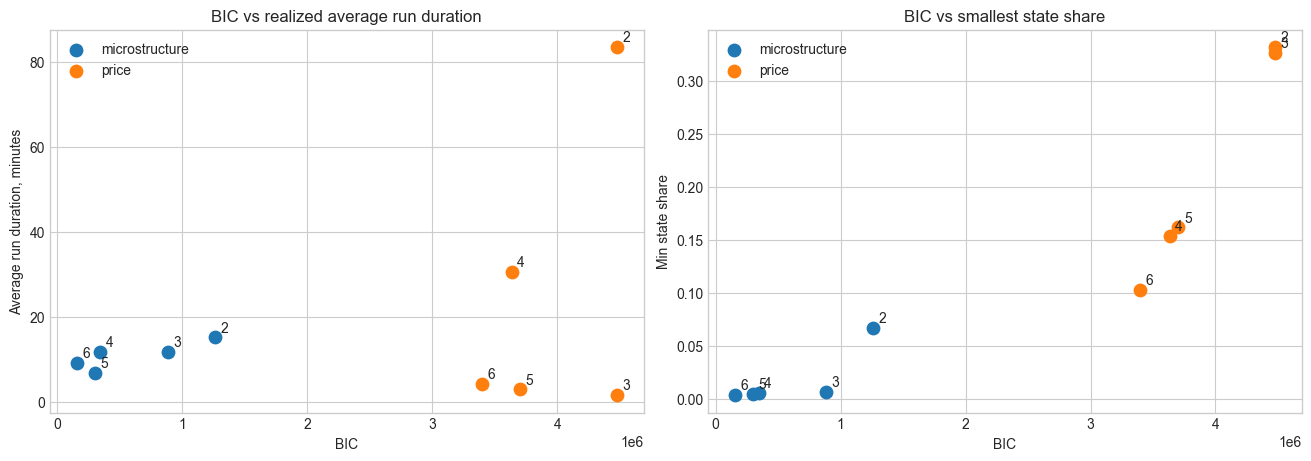

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
ok_metrics = metrics.loc[metrics['status'].eq('ok')].copy()

for model_family, group in ok_metrics.groupby('model_family'):
    axes[0].scatter(group['bic'], group['average_sequence_duration'], s=80, label=model_family)
    axes[1].scatter(group['bic'], group['min_state_share'], s=80, label=model_family)
    for _, row in group.iterrows():
        axes[0].annotate(int(row['n_components']), (row['bic'], row['average_sequence_duration']), xytext=(4, 4), textcoords='offset points')
        axes[1].annotate(int(row['n_components']), (row['bic'], row['min_state_share']), xytext=(4, 4), textcoords='offset points')

axes[0].set_title('BIC vs realized average run duration')
axes[0].set_xlabel('BIC')
axes[0].set_ylabel('Average run duration, minutes')
axes[1].set_title('BIC vs smallest state share')
axes[1].set_xlabel('BIC')
axes[1].set_ylabel('Min state share')
for ax in axes:
    ax.legend()
plt.show()


## Best model state profiles

In [7]:
base_profile_columns = ['model_family', 'state', 'count', 'share', 'self_transition']
profiles.loc[:, base_profile_columns].sort_values(['model_family', 'state'])


,model_family,state,count,share,self_transition
6,microstructure,0,104311,0.197919,0.823325
7,microstructure,1,1896,0.003597,0.000000
8,microstructure,2,46666,0.088544,0.718347
9,microstructure,3,151590,0.287625,0.931081
10,microstructure,4,7840,0.014876,0.000000
11,microstructure,5,214737,0.407440,0.938884
0,price,0,57343,0.108802,0.283219
1,price,1,99968,0.189678,0.969021
2,price,2,118560,0.224954,0.952995
3,price,3,54231,0.102897,0.001077


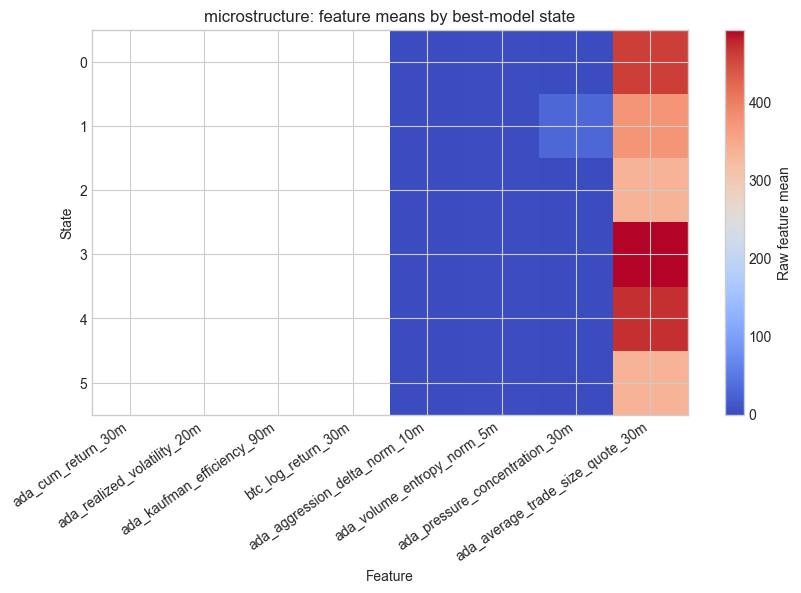

,ada_cum_return_30m,ada_realized_volatility_20m,ada_kaufman_efficiency_90m,btc_log_return_30m,ada_aggression_delta_norm_10m,ada_volume_entropy_norm_5m,ada_pressure_concentration_30m,ada_average_trade_size_quote_30m
state,,,,,,,,
0,NaN,NaN,NaN,NaN,-0.006769,0.834759,-0.325938,458.095853
1,NaN,NaN,NaN,NaN,-0.000785,0.805394,30.663440,373.872518
2,NaN,NaN,NaN,NaN,-0.002576,0.778178,-0.311391,332.799823
3,NaN,NaN,NaN,NaN,-0.022812,0.836517,-0.807263,492.335999
4,NaN,NaN,NaN,NaN,-0.001863,0.837403,-1.642491,471.088094
5,NaN,NaN,NaN,NaN,-0.009470,0.796030,-0.649977,333.391229


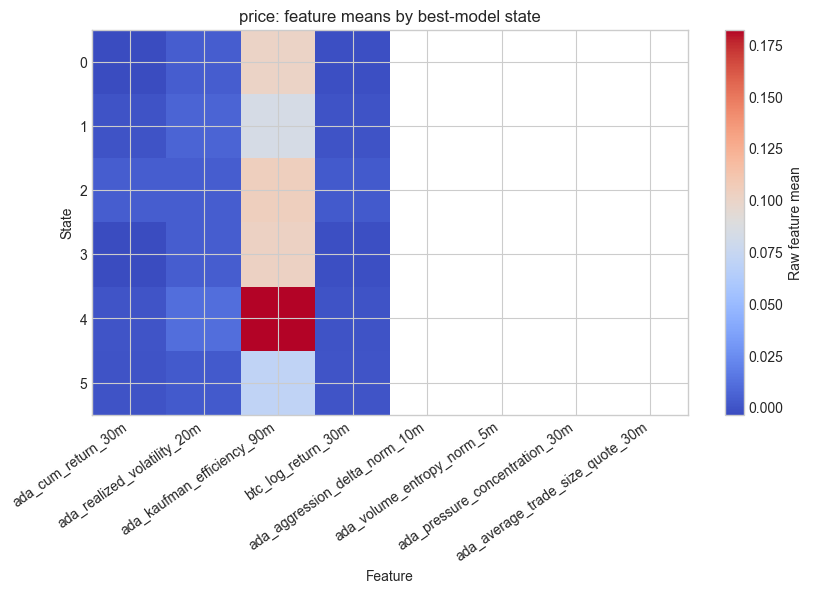

,ada_cum_return_30m,ada_realized_volatility_20m,ada_kaufman_efficiency_90m,btc_log_return_30m,ada_aggression_delta_norm_10m,ada_volume_entropy_norm_5m,ada_pressure_concentration_30m,ada_average_trade_size_quote_30m
state,,,,,,,,
0,-0.003405,0.004001,0.100876,-0.001805,NaN,NaN,NaN,NaN
1,-0.000433,0.007206,0.083903,-0.000316,NaN,NaN,NaN,NaN
2,0.003702,0.003945,0.104362,0.002206,NaN,NaN,NaN,NaN
3,-0.003645,0.004048,0.102094,-0.001939,NaN,NaN,NaN,NaN
4,0.000515,0.011521,0.182257,-0.000130,NaN,NaN,NaN,NaN
5,-0.000081,0.002495,0.070824,0.000084,NaN,NaN,NaN,NaN


In [8]:
for model_family, profile in profiles.groupby('model_family'):
    mean_columns = [column for column in profile.columns if column.endswith('_mean')]
    heatmap = profile.set_index('state')[mean_columns].copy()
    heatmap.columns = [column.removesuffix('_mean') for column in heatmap.columns]
    fig, ax = plt.subplots(figsize=(max(7, len(mean_columns) * 1.2), 0.8 + len(heatmap) * 0.7))
    image = ax.imshow(heatmap.to_numpy(dtype='float64'), aspect='auto', cmap='coolwarm')
    ax.set_title(f'{model_family}: feature means by best-model state')
    ax.set_xlabel('Feature')
    ax.set_ylabel('State')
    ax.set_xticks(np.arange(len(heatmap.columns)), labels=heatmap.columns, rotation=35, ha='right')
    ax.set_yticks(np.arange(len(heatmap.index)), labels=heatmap.index)
    fig.colorbar(image, ax=ax, label='Raw feature mean')
    plt.show()
    display(heatmap)


## State dynamics

In [9]:
daily_state_shares = (
    states.assign(date=states['timestamp'].dt.floor('D'))
    .groupby(['model_family', 'date', 'state'])
    .size()
    .rename('minutes')
    .reset_index()
)
daily_state_shares['share'] = daily_state_shares['minutes'] / daily_state_shares.groupby(['model_family', 'date'])['minutes'].transform('sum')
daily_state_shares.head()


,model_family,date,state,minutes,share
0,microstructure,2024-02-01 00:00:00+00:00,0,543,0.377083
1,microstructure,2024-02-01 00:00:00+00:00,1,7,0.004861
2,microstructure,2024-02-01 00:00:00+00:00,2,41,0.028472
3,microstructure,2024-02-01 00:00:00+00:00,3,717,0.497917
4,microstructure,2024-02-01 00:00:00+00:00,4,35,0.024306


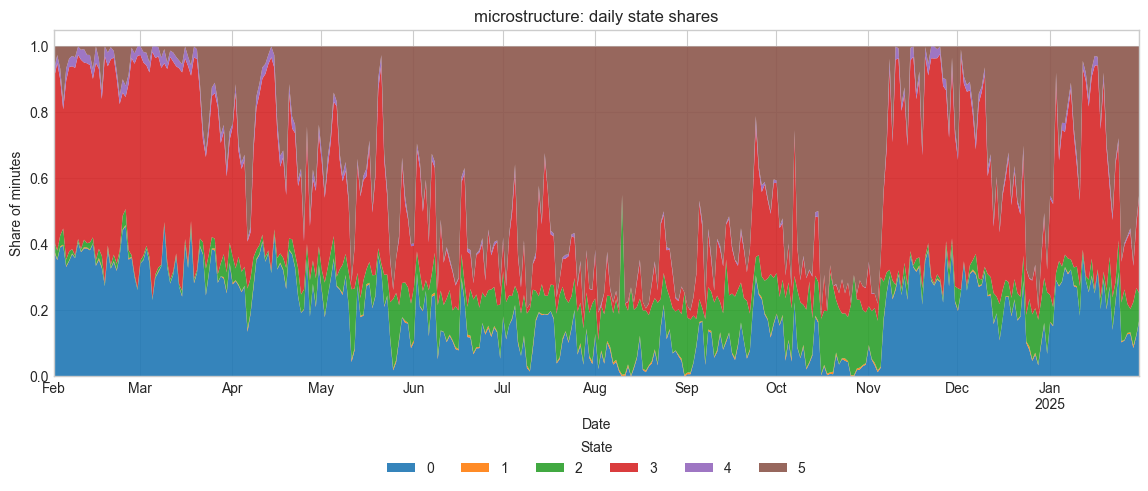

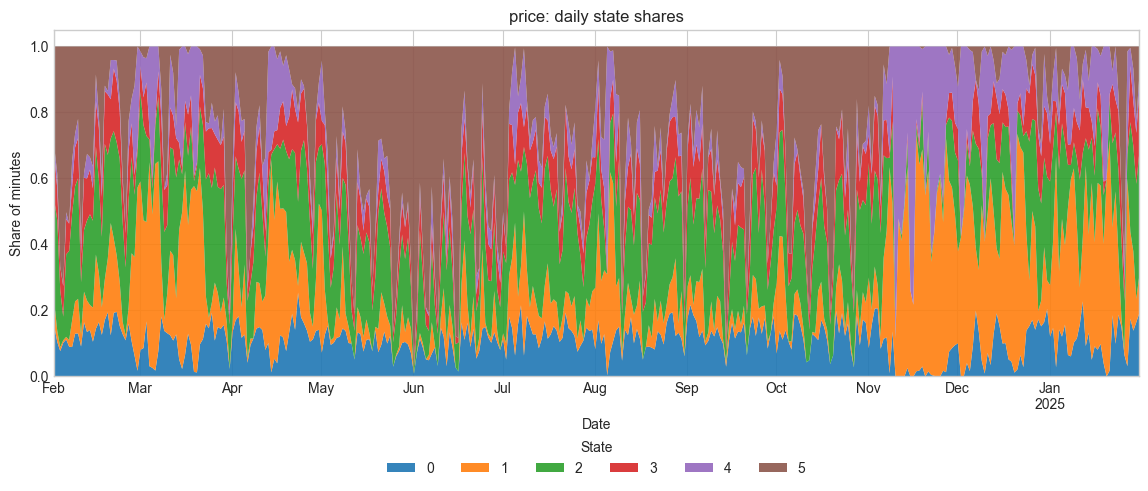

In [10]:
for model_family, group in daily_state_shares.groupby('model_family'):
    pivot = group.pivot(index='date', columns='state', values='share').fillna(0.0).sort_index()
    ax = pivot.plot.area(figsize=(14, 4.5), linewidth=0, alpha=0.9)
    ax.set_title(f'{model_family}: daily state shares')
    ax.set_xlabel('Date')
    ax.set_ylabel('Share of minutes')
    ax.legend(title='State', ncol=min(len(pivot.columns), 6), loc='upper center', bbox_to_anchor=(0.5, -0.15))
    plt.show()


In [11]:
transition_tables = []
for model_family, family_states in states.sort_values(['model_family', 'timestamp']).groupby('model_family'):
    previous_state = family_states['state'].shift(1)
    valid = previous_state.notna()
    transition = pd.crosstab(previous_state[valid].astype(int), family_states.loc[valid, 'state'].astype(int), normalize='index')
    transition.index.name = 'from_state'
    transition.columns.name = 'to_state'
    transition_tables.append((model_family, transition))
    print(f'\n{model_family}: empirical transition matrix')
    display(transition)



microstructure: empirical transition matrix


to_state,0,1,2,3,4,5
from_state,,,,,,
0,0.850275,0.003537,0.004678,0.070204,0.057520,0.013786
1,0.222574,0.000000,0.655591,0.000527,0.000000,0.121308
2,0.020229,0.025715,0.733403,0.002229,0.025800,0.192624
3,0.041414,0.000297,0.001709,0.946283,0.004196,0.006102
4,0.814796,0.000000,0.160842,0.024362,0.000000,0.000000
5,0.007386,0.001313,0.042797,0.002436,0.000000,0.946069



price: empirical transition matrix


to_state,0,1,2,3,4,5
from_state,,,,,,
0,0.005406,0.000000,0.036290,0.927419,0.000000,0.030884
1,0.000000,0.972291,0.009353,0.009373,0.008983,0.000000
2,0.017704,0.005575,0.957397,0.000000,0.002606,0.016717
3,0.977393,0.017628,0.000000,0.000000,0.004979,0.000000
4,0.000000,0.021106,0.004302,0.002087,0.972505,0.000000
5,0.013503,0.000070,0.012621,0.000000,0.000084,0.973722


## Summary objects

In [12]:
summary_rows = []
for model_family, summary in summaries.items():
    best = summary['best_model']
    summary_rows.append(
        {
            'model_family': model_family,
            'features': ', '.join(summary['features']),
            'best_n_components': best['n_components'],
            'best_bic': best['bic'],
            'best_aic': best['aic'],
            'min_state_share': best['min_state_share'],
            'average_sequence_duration': best['average_sequence_duration'],
            'result_prefix': summary['result_prefix'],
        }
    )

pd.DataFrame(summary_rows)


,model_family,features,best_n_components,best_bic,best_aic,min_state_share,average_sequence_duration,result_prefix
0,price,"ada_cum_return_30m, ada_realized_volatility_20...",6,3.399340e+06,3.398412e+06,0.102755,4.239144,analysis/hmm_price_factor_models_v1
1,microstructure,"ada_aggression_delta_norm_10m, ada_volume_entr...",6,1.552845e+05,1.543569e+05,0.003597,9.162726,analysis/hmm_microstructure_factor_models_v1
